In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

import joblib
import os
import json

print(' All libraries imported successfully')

 All libraries imported successfully


In [17]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/yield_df.csv')
print(f'Shape: {df.shape}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [18]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/yield_df.csv')
print(f'Shape: {df.shape}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (28242, 8)


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [19]:
print(df.dtypes)
print('\nMissing values:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df.describe()

Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object

Missing values: 0
Duplicates: 0


,Unnamed: 0,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
count,28242.000000,28242.000000,28242.000000,28242.00000,28242.000000,28242.000000
mean,14120.500000,2001.544296,77053.332094,1149.05598,37076.909344,20.542627
std,8152.907488,7.051905,84956.612897,709.81215,59958.784665,6.312051
min,0.000000,1990.000000,50.000000,51.00000,0.040000,1.300000
25%,7060.250000,1995.000000,19919.250000,593.00000,1702.000000,16.702500
50%,14120.500000,2001.000000,38295.000000,1083.00000,17529.440000,21.510000
75%,21180.750000,2008.000000,104676.750000,1668.00000,48687.880000,26.000000
max,28241.000000,2013.000000,501412.000000,3240.00000,367778.000000,30.650000


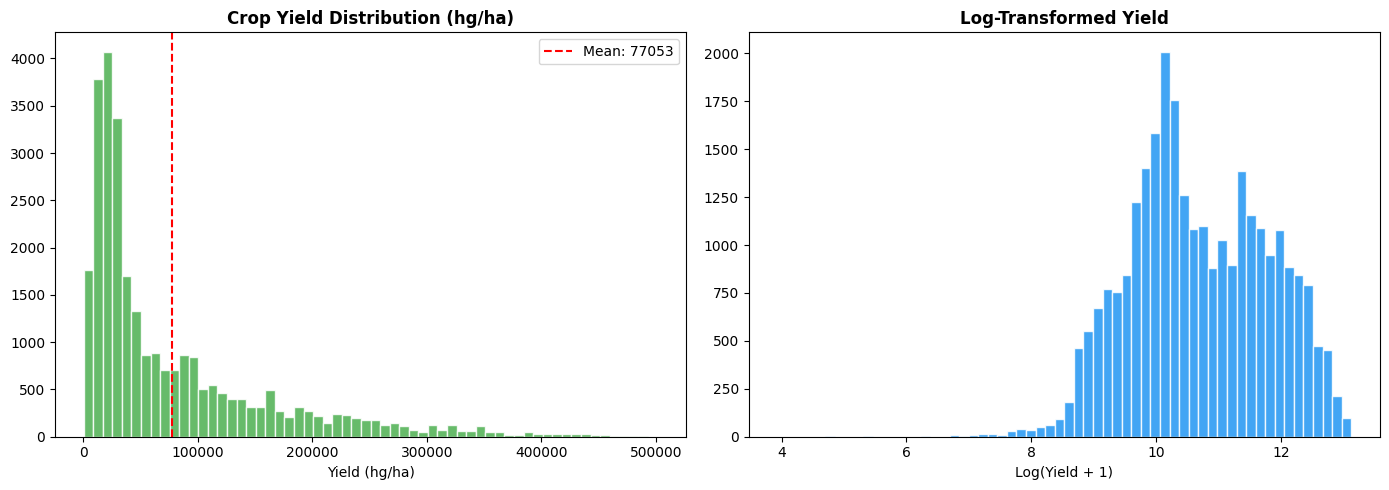

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['hg/ha_yield'], bins=60, color='#4CAF50', edgecolor='white', alpha=0.85)
axes[0].set_title('Crop Yield Distribution (hg/ha)', fontweight='bold')
axes[0].set_xlabel('Yield (hg/ha)')
axes[0].axvline(df['hg/ha_yield'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['hg/ha_yield'].mean():.0f}")
axes[0].legend()

axes[1].hist(np.log1p(df['hg/ha_yield']), bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Yield', fontweight='bold')
axes[1].set_xlabel('Log(Yield + 1)')

plt.tight_layout()
plt.savefig('yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
# Interpretation: raw distribution is right-skewed; log transform normalizes it
# which improves linear regression assumptions

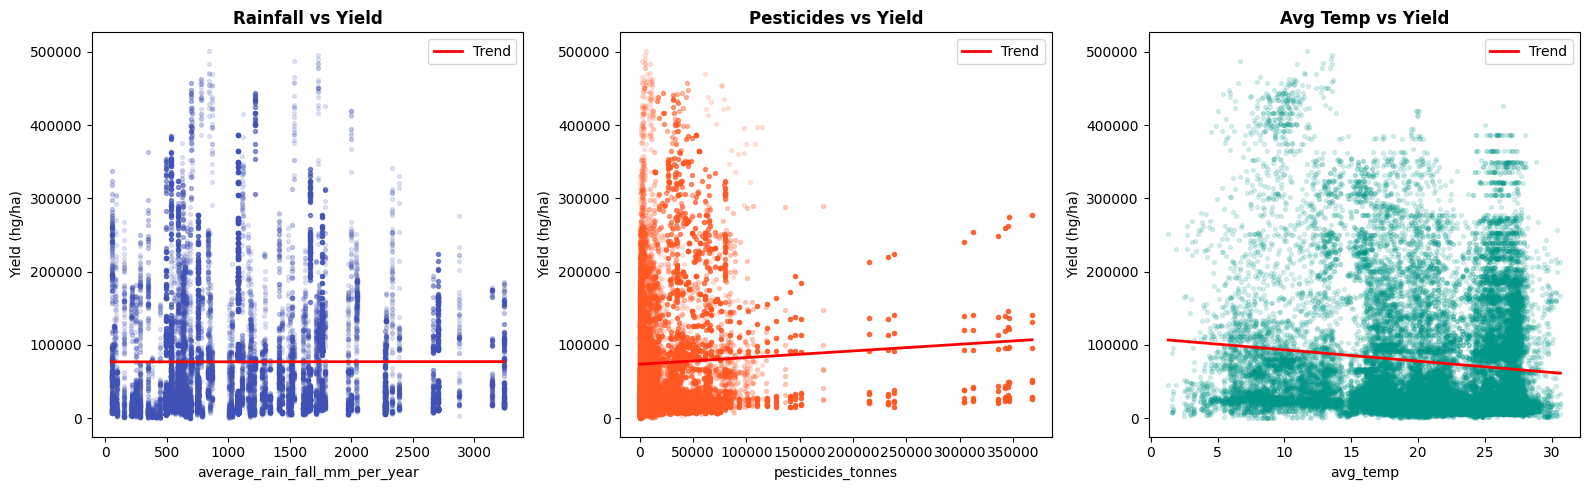

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

features = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
colors   = ['#3F51B5', '#FF5722', '#009688']
titles   = ['Rainfall vs Yield', 'Pesticides vs Yield', 'Avg Temp vs Yield']

for ax, feat, col, title in zip(axes, features, colors, titles):
    ax.scatter(df[feat], df['hg/ha_yield'], alpha=0.15, s=8, color=col)
    z = np.polyfit(df[feat].dropna(), df.loc[df[feat].notna(), 'hg/ha_yield'], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 200)
    ax.plot(x_line, np.poly1d(z)(x_line), color='red', linewidth=2, label='Trend')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Yield (hg/ha)')
    ax.legend()

plt.tight_layout()
plt.savefig('feature_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
# Interpretation: rainfall & pesticides show positive trends; high temp slightly reduces yield

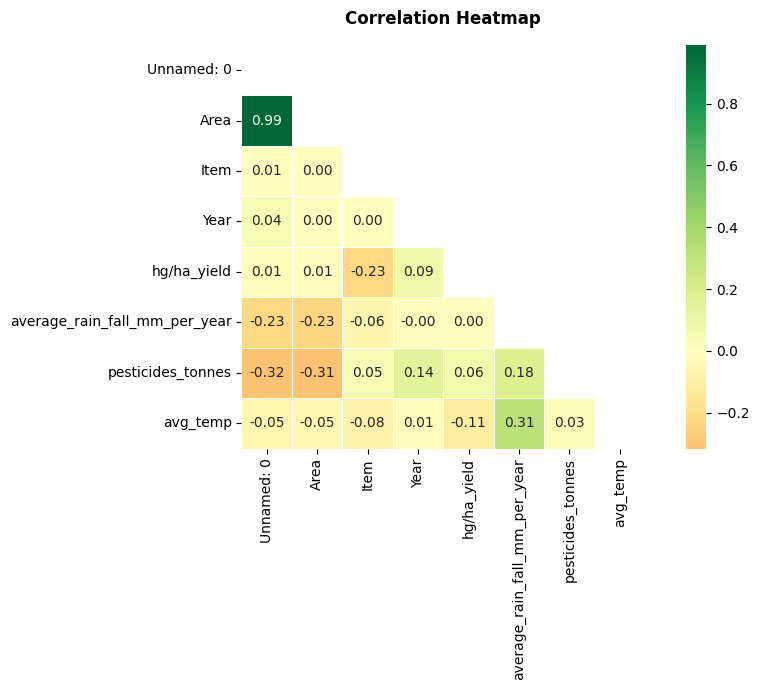

In [22]:
df_corr = df.copy()
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col].astype(str))

plt.figure(figsize=(10, 7))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            mask=np.triu(np.ones_like(df_corr.corr(), dtype=bool)))
plt.title('Correlation Heatmap', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
# Interpretation: pesticides_tonnes has the strongest correlation with yield,
# followed by rainfall. avg_temp is weakly negative.

In [23]:
TARGET = 'hg/ha_yield'

# Drop index column if present, remove duplicates and nulls
df_clean = df.drop(columns=[c for c in ['Unnamed: 0'] if c in df.columns], errors='ignore')
df_clean = df_clean.drop_duplicates().dropna().reset_index(drop=True)

# Encode categorical columns (Area = country, Item = crop)
label_encoders = {}
for col in df_clean.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    label_encoders[col] = le
    print(f'Encoded: {col} → {df_clean[col].nunique()} classes')

joblib.dump(label_encoders, 'label_encoders.pkl')

X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]
print(f'\nFeatures: {X.columns.tolist()}')
print(f'Dataset ready: {X.shape}')

Encoded: Area → 101 classes
Encoded: Item → 10 classes

Features: ['Area', 'Item', 'Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
Dataset ready: (25932, 6)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit+transform on train
X_test_scaled  = scaler.transform(X_test)        # transform only on test

joblib.dump(scaler, 'scaler.pkl')
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(' Scaler saved')

Train: 20745 | Test: 5187
 Scaler saved


In [25]:
# --- sklearn Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test  = lr_model.predict(X_test_scaled)
lr_train_mse = mean_squared_error(y_train, y_pred_lr_train)
lr_test_mse  = mean_squared_error(y_test,  y_pred_lr_test)
lr_r2        = r2_score(y_test, y_pred_lr_test)
print(f'Linear Regression — Train MSE: {lr_train_mse:,.2f} | Test MSE: {lr_test_mse:,.2f} | R²: {lr_r2:.4f}')



Linear Regression — Train MSE: 6,571,538,890.63 | Test MSE: 6,668,570,971.77 | R²: 0.0799


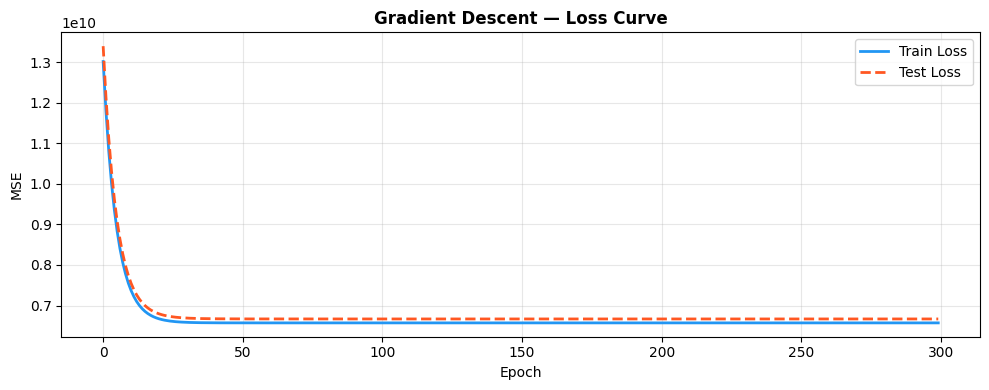

In [26]:
# --- Manual Gradient Descent (for loss curve) ---
y_tr = y_train.values
y_te = y_test.values
theta, bias = np.zeros(X_train_scaled.shape[1]), 0.0
train_losses, test_losses = [], []

for _ in range(300):
    error = X_train_scaled @ theta + bias - y_tr
    train_losses.append(np.mean(error ** 2))
    test_losses.append(np.mean((X_test_scaled @ theta + bias - y_te) ** 2))
    theta -= 0.05 * (2 / len(y_tr)) * (X_train_scaled.T @ error)
    bias  -= 0.05 * (2 / len(y_tr)) * np.sum(error)

# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss', color='#2196F3', linewidth=2)
plt.plot(test_losses,  label='Test Loss',  color='#FF5722', linewidth=2, linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Gradient Descent — Loss Curve', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()



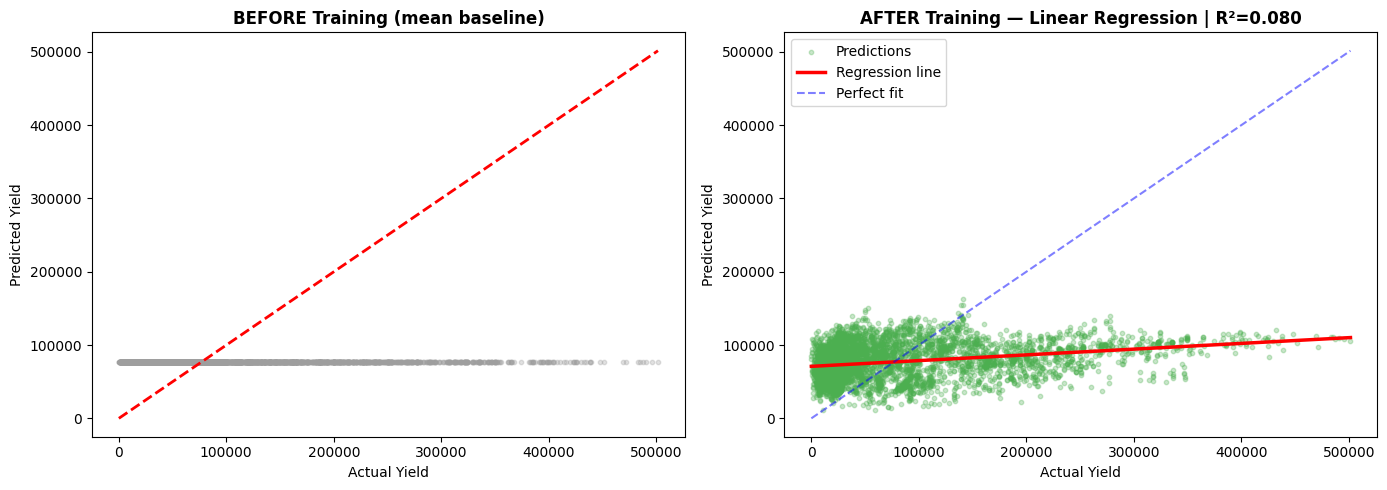

In [27]:
# Before vs After scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_te, np.full_like(y_te, y_tr.mean()), alpha=0.3, s=10, color='#9E9E9E')
axes[0].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', linewidth=2)
axes[0].set_title('BEFORE Training (mean baseline)', fontweight='bold')
axes[0].set_xlabel('Actual Yield'); axes[0].set_ylabel('Predicted Yield')

axes[1].scatter(y_te, y_pred_lr_test, alpha=0.3, s=10, color='#4CAF50', label='Predictions')
x_s = np.sort(y_te)
axes[1].plot(x_s, np.poly1d(np.polyfit(y_te, y_pred_lr_test, 1))(x_s), 'r-', linewidth=2.5, label='Regression line')
axes[1].plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'b--', linewidth=1.5, alpha=0.5, label='Perfect fit')
axes[1].set_title(f'AFTER Training — Linear Regression | R²={lr_r2:.3f}', fontweight='bold')
axes[1].set_xlabel('Actual Yield'); axes[1].set_ylabel('Predicted Yield'); axes[1].legend()

plt.tight_layout()
plt.savefig('scatter_before_after.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# Decision Tree
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train_scaled, y_train)
dt_test_mse  = mean_squared_error(y_test, dt_model.predict(X_test_scaled))
dt_train_mse = mean_squared_error(y_train, dt_model.predict(X_train_scaled))
dt_r2        = r2_score(y_test, dt_model.predict(X_test_scaled))
print(f'Decision Tree  — Train MSE: {dt_train_mse:,.2f} | Test MSE: {dt_test_mse:,.2f} | R²: {dt_r2:.4f}')

# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
rf_test_mse  = mean_squared_error(y_test, rf_model.predict(X_test_scaled))
rf_train_mse = mean_squared_error(y_train, rf_model.predict(X_train_scaled))
rf_r2        = r2_score(y_test, rf_model.predict(X_test_scaled))
print(f'Random Forest  — Train MSE: {rf_train_mse:,.2f} | Test MSE: {rf_test_mse:,.2f} | R²: {rf_r2:.4f}')

Decision Tree  — Train MSE: 209,330,055.76 | Test MSE: 350,291,364.69 | R²: 0.9517
Random Forest  — Train MSE: 20,343,114.61 | Test MSE: 125,007,284.99 | R²: 0.9828


=== Model Comparison ===
            Model    Train MSE     Test MSE  Test R²
    Random Forest 2.034311e+07 1.250073e+08 0.982753
    Decision Tree 2.093301e+08 3.502914e+08 0.951670
Linear Regression 6.571539e+09 6.668571e+09 0.079929

 Best model: Random Forest — saved as best_model.pkl


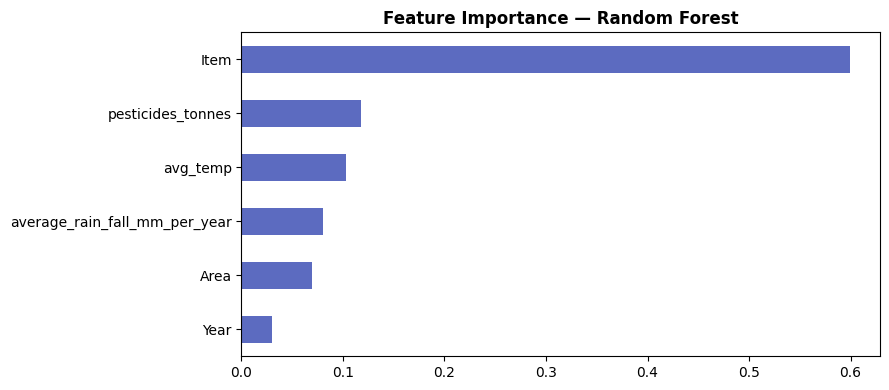

In [29]:
results = pd.DataFrame({
    'Model':     ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'Train MSE': [lr_train_mse, dt_train_mse, rf_train_mse],
    'Test MSE':  [lr_test_mse,  dt_test_mse,  rf_test_mse],
    'Test R²':   [lr_r2,        dt_r2,        rf_r2]
}).sort_values('Test MSE').reset_index(drop=True)

print('=== Model Comparison ===')
print(results.to_string(index=False))

# Save best model
model_map       = {'Linear Regression': lr_model, 'Decision Tree': dt_model, 'Random Forest': rf_model}
best_model_name = results.iloc[0]['Model']
best_model      = model_map[best_model_name]

joblib.dump(best_model, 'best_model.pkl')
json.dump({'model': best_model_name, 'test_mse': round(results.iloc[0]['Test MSE'], 2),
           'test_r2': round(results.iloc[0]['Test R²'], 4), 'features': X.columns.tolist()},
          open('model_metadata.json', 'w'), indent=2)
print(f'\n Best model: {best_model_name} — saved as best_model.pkl')

# Feature Importance
importances = (pd.Series(best_model.feature_importances_, index=X.columns)
               if hasattr(best_model, 'feature_importances_')
               else pd.Series(np.abs(best_model.coef_), index=X.columns))

importances.sort_values().plot(kind='barh', color='#5C6BC0', figsize=(9, 4))
plt.title(f'Feature Importance — {best_model_name}', fontweight='bold')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
def predict_crop_yield(area, item, year, rainfall, pesticides, avg_temp):
    """Returns predicted crop yield in hg/ha."""
    encoders = joblib.load('label_encoders.pkl')
    sc       = joblib.load('scaler.pkl')
    model    = joblib.load('best_model.pkl')

    input_df = pd.DataFrame([{
        'Area': encoders['Area'].transform([area])[0],
        'Item': encoders['Item'].transform([item])[0],
        'Year': year,
        'average_rain_fall_mm_per_year': rainfall,
        'pesticides_tonnes': pesticides,
        'avg_temp': avg_temp
    }])[X.columns]

    return round(float(model.predict(sc.transform(input_df))[0]), 2)


# Test on one row from test set
sample    = X_test.iloc[[0]]
actual    = y_test.iloc[0]
predicted = predict_crop_yield(
    area       = label_encoders['Area'].inverse_transform([int(sample['Area'].values[0])])[0],
    item       = label_encoders['Item'].inverse_transform([int(sample['Item'].values[0])])[0],
    year       = int(sample['Year'].values[0]),
    rainfall   = float(sample['average_rain_fall_mm_per_year'].values[0]),
    pesticides = float(sample['pesticides_tonnes'].values[0]),
    avg_temp   = float(sample['avg_temp'].values[0])
)

print(f'Actual Yield    : {actual:,.0f} hg/ha')
print(f'Predicted Yield : {predicted:,.2f} hg/ha')
print(f'Error           : {abs(predicted - actual):,.0f} hg/ha')

Actual Yield    : 155,782 hg/ha
Predicted Yield : 155,374.04 hg/ha
Error           : 408 hg/ha
